
[Generating GIF: anim_rho.gif]
Computing frame 80/80...
-> Saved successfully: anim_rho.gif

[Generating GIF: anim_delta.gif]
Computing frame 80/80...
-> Saved successfully: anim_delta.gif

[Generating GIF: anim_dtau.gif]
Computing frame 80/80...
-> Saved successfully: anim_dtau.gif

[Generating GIF: anim_r.gif]
Computing frame 80/80...
-> Saved successfully: anim_r.gif

Done! You can now open the 4 GIF files.


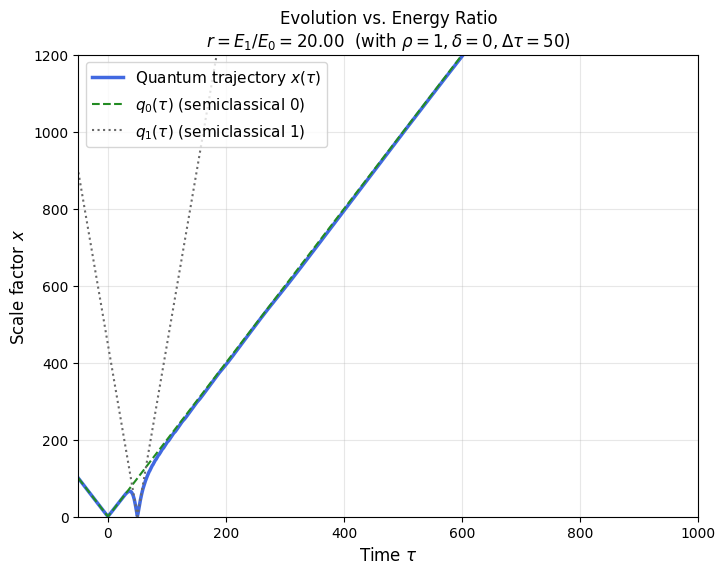

In [6]:
"""
Quantum Biverse Trajectories: Animation Generators (rho, delta, Dtau, r)
Generates 4 GIF files illustrating the dynamic evolution of the trajectories.
Includes the semiclassical asymptotes q0 and q1.
"""

import numpy as np
import math
from scipy.integrate import solve_ivp, quad
from scipy.special import gamma, genlaguerre
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sys

# ─────────────────────────────────────────────
# 1. GLOBAL MODEL PARAMETERS
# ─────────────────────────────────────────────
nu      = 1
n0      = 0
n1      = 0
E0      = 1.0  # state 0's energy stays fixed at 1.0

# ξ is the normalization/overlap constant of the n-th affine coherent state,
# obtained by numerically integrating the weighted squared Laguerre polynomial
def compute_xi(n_val, nu_val):
    Ln_func = genlaguerre(n_val, nu_val)
    def integrand(y):
        return y**(nu_val + 0.5) * (Ln_func(y))**2 * np.exp(-y)
    integral_val, _ = quad(integrand, 0, np.inf)
    Gn = (math.factorial(n_val) / gamma(nu_val + n_val + 1)) * integral_val
    return Gn**2

xi0 = compute_xi(n0, nu)
xi1 = compute_xi(n1, nu)

# Constant parameters for state 0
qB0 = xi0 / np.sqrt(E0)
om0 = 2 * E0 / xi0
tB0 = 0.0

# Constant parameters for state 1 (E1 is rescaled dynamically according to r)
qB1 = xi1 / np.sqrt(E0)  # initially based on E0, recomputed later depending on r
om1 = 2 * E0 * 2 / xi1
tB1 = 50.0  # initial Dtau value for state 1's bounce time

coeff_N0 = math.sqrt(math.factorial(n0) / gamma(nu + n0 + 1))
coeff_N1 = math.sqrt(math.factorial(n1) / gamma(nu + n1 + 1))
constant_ratio = (coeff_N1 / coeff_N0) * ((xi1 / xi0)**((nu + 1) / 2.0))

# ─────────────────────────────────────────────
# 2. BASE FUNCTIONS & GUIDANCE
# ─────────────────────────────────────────────
def q_sc(t, qB, om, tB):
    return qB * np.sqrt(1.0 + om**2 * (t - tB)**2)

def p_sc(t, qB, om, tB):
    dt = t - tB
    return 0.5 * qB * om**2 * dt / np.sqrt(1.0 + om**2 * dt**2)

def get_alpha_q(tau, qB, om, tB, xi_val):
    # alpha (α) is the complex Gaussian spread parameter of the wavefunction
    # branch: Re(α) = xi sets its width via q, Im(α) = -q*p carries the phase curvature
    q = q_sc(tau, qB, om, tB)
    p = p_sc(tau, qB, om, tB)
    return xi_val - 1j*q*p, q

L_n0   = genlaguerre(n0, nu)
L_n0_m1 = genlaguerre(n0 - 1, nu + 1) if n0 > 0 else lambda y: np.zeros_like(y)
L_n1   = genlaguerre(n1, nu)
L_n1_m1 = genlaguerre(n1 - 1, nu + 1) if n1 > 0 else lambda y: np.zeros_like(y)

# ── r_val is added to the guidance function's parameters so state 1's energy
#    (and thus qB1, om1) can be swept alongside rho/delta/Dtau ──
def guidance_rhs(tau, state, rho_val, delta_val, tB1_val, r_val):
    x = state[0]

    # Dynamically recompute state 1's properties as a function of r
    E1_val = r_val * E0
    qB1_val = xi1 / np.sqrt(E1_val)
    om1_val = 2 * E1_val / xi1

    al0, q0 = get_alpha_q(tau, qB0, om0, tB0, xi0)
    al1, q1 = get_alpha_q(tau, qB1_val, om1_val, tB1_val, xi1)

    y0, y1 = xi0 * (x**2) / (q0**2), xi1 * (x**2) / (q1**2)
    eps = 1e-300  # avoids a 0/0 division right at the nodes of the Laguerre polynomials
    val_L0, val_L1 = L_n0(y0) + eps, L_n1(y1) + eps

    term_L0 = 2.0 * xi0 * (x / q0**2) * L_n0_m1(y0) / val_L0 if n0 > 0 else 0.0
    term_L1 = 2.0 * xi1 * (x / q1**2) * L_n1_m1(y1) / val_L1 if n1 > 0 else 0.0

    f0 = (nu + 0.5)/x - term_L0 - al0 * x / q0**2
    f1 = (nu + 0.5)/x - term_L1 - al1 * x / q1**2

    power_phase0, power_phase1 = (2*n0 + nu + 1)/2.0, (2*n1 + nu + 1)/2.0
    ratio_q = (q0/q1)**(nu + 1)
    ratio_alpha = (al1 / np.conj(al1))**power_phase1 / (al0 / np.conj(al0))**power_phase0
    poly_ratio = val_L1 / val_L0
    exp_arg = 0.5 * x**2 * (al0/q0**2 - al1/q1**2)

    # w = psi_1/psi_0, weighted by the biverse amplitude ratio rho and phase delta
    w = rho_val * np.exp(-1j*delta_val) * constant_ratio * ratio_q * ratio_alpha * poly_ratio * np.exp(exp_arg)
    return [2.0 * np.imag((f0 + w*f1) / (1.0 + w))]

def compute_trajectory(rho_val, delta_val, Dtau_val, r_val, tau_eval):
    x_i = q_sc(tau_eval[0], qB0, om0, tB0)
    sol = solve_ivp(
        guidance_rhs, (tau_eval[0], tau_eval[-1]), [x_i],
        method='RK45', t_eval=tau_eval,
        rtol=1e-6, atol=1e-8,
        args=(rho_val, delta_val, Dtau_val, r_val)
    )
    # Crash-avoidance workaround: return both sol.t and sol.y[0], since a
    # failed/incomplete integration yields fewer points than tau_eval and the
    # caller must plot against the actual (shorter) sol.t rather than tau_eval
    return sol.t, sol.y[0]

# ─────────────────────────────────────────────
# 3. ANIMATION ENGINE
# ─────────────────────────────────────────────
tau_traj = np.linspace(-50.0, 1000.0, 1000)
num_frames = 80  # number of frames per GIF

fig, ax = plt.subplots(figsize=(8, 6))

line, = ax.plot([], [], color='royalblue', lw=2.5, label="Quantum trajectory $x(\\tau)$")
line_q0, = ax.plot([], [], color='forestgreen', ls='--', lw=1.5, label="$q_0(\\tau)$ (semiclassical 0)")
line_q1, = ax.plot([], [], color='dimgray', ls=':', lw=1.5, label="$q_1(\\tau)$ (semiclassical 1)")

title = ax.set_title("")
ax.set_xlim(-50, 1000)
ax.set_ylim(0, 1200)
ax.set_xlabel('Time $\\tau$', fontsize=12)
ax.set_ylabel('Scale factor $x$', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=11)

def build_gif(param_name, param_array, fixed_rho, fixed_delta, fixed_dtau, fixed_r, filename):
    print(f"\n[Generating GIF: {filename}]")

    def update(frame):
        sys.stdout.write(f"\rComputing frame {frame+1}/{num_frames}...")
        sys.stdout.flush()

        current_val = param_array[frame]

        # Assign the swept parameter dynamically, keep the others fixed
        rho_val = current_val if param_name == 'rho' else fixed_rho
        delta_val = current_val if param_name == 'delta' else fixed_delta
        dtau_val = current_val if param_name == 'Dtau' else fixed_dtau
        r_val = current_val if param_name == 'r' else fixed_r

        # Recompute the q1 asymptote as a function of both Dtau and r
        E1_val = r_val * E0
        qB1_val = xi1 / np.sqrt(E1_val)
        om1_val = 2 * E1_val / xi1

        q0_res = q_sc(tau_traj, qB0, om0, tB0)
        q1_res = q_sc(tau_traj, qB1_val, om1_val, dtau_val)

        # Compute the quantum trajectory (using the actual t_res to avoid the crash above)
        t_res, x_res = compute_trajectory(rho_val, delta_val, dtau_val, r_val, tau_traj)

        # Update the curves
        line.set_data(t_res, x_res)
        line_q0.set_data(tau_traj, q0_res)
        line_q1.set_data(tau_traj, q1_res)

        # Title formatting
        if param_name == 'rho':
            title.set_text(f"Evolution vs. Amplitude\n$\\rho = {current_val:.2f}$  (with $r=2, \\delta=0, \\Delta\\tau=50$)")
        elif param_name == 'delta':
            title.set_text(f"Evolution vs. Phase\n$\\delta = {current_val:.2f}$ rad  (with $r=2, \\rho=1, \\Delta\\tau=50$)")
        elif param_name == 'Dtau':
            title.set_text(f"Evolution vs. Time Delay\n$\\Delta\\tau = {current_val:.1f}$  (with $r=2, \\rho=1, \\delta=0$)")
        elif param_name == 'r':
            title.set_text(f"Evolution vs. Energy Ratio\n$r = E_1/E_0 = {current_val:.2f}$  (with $\\rho=1, \\delta=0, \\Delta\\tau=50$)")

        return line, line_q0, line_q1, title

    # Build and save the animation
    ani = animation.FuncAnimation(fig, update, frames=num_frames, blit=True)
    ani.save(filename, writer='pillow', fps=10)
    print(f"\n-> Saved successfully: {filename}")


# ── Run all 4 generations ──

# GIF 1: sweep rho (0.1 to 80.0)
rho_values = np.linspace(0.1, 80.0, num_frames)
build_gif('rho', rho_values, fixed_rho=None, fixed_delta=0.0, fixed_dtau=50.0, fixed_r=2.0, filename="anim_rho.gif")

# GIF 2: sweep delta (0 to 4*pi)
delta_values = np.linspace(0.0, 4*np.pi, num_frames)
build_gif('delta', delta_values, fixed_rho=1.0, fixed_delta=None, fixed_dtau=50.0, fixed_r=2.0, filename="anim_delta.gif")

# GIF 3: sweep Dtau (0 to 1000)
dtau_values = np.linspace(0.0, 1000.0, num_frames)
build_gif('Dtau', dtau_values, fixed_rho=1.0, fixed_delta=0.0, fixed_dtau=None, fixed_r=2.0, filename="anim_dtau.gif")

# GIF 4: sweep r (0.5 to 20.0)
r_values = np.linspace(0.5, 20.0, num_frames)
build_gif('r', r_values, fixed_rho=1.0, fixed_delta=0.0, fixed_dtau=50.0, fixed_r=None, filename="anim_r.gif")

print("\nDone! You can now open the 4 GIF files.")
